In [1]:
import xarray as xr

path = '/Users/nalex2023/main/LSB_main/LSB_APP/Docker_files/projects/Manus/Datasets/twpmetC1.b1/'

test = xr.open_mfdataset(f'{path}*.cdf')

/Users/nalex2023/miniconda3/envs/nma/lib/python3.12/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'cfgrib' loading failed:
module 'cfgrib.messages' has no attribute 'DEFAULT_INDEXPATH'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)
/var/folders/bt/kswp83jx5mj4bn1bjkh9g4rsg_b7ks/T/ipykernel_71903/1544891372.py:5: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  test = xr.open_mfdataset(f'{path}*.cdf')


In [4]:
test

<xarray.Dataset> Size: 88MB
Dimensions:                       (time: 308160)
Coordinates:
  * time                          (time) datetime64[ns] 2MB 2011-10-01 ... 20...
Data variables: (12/61)
    base_time                     (time) datetime64[ns] 2MB 2011-10-01 ... 20...
    time_offset                   (time) datetime64[ns] 2MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_time                       (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    atmos_pressure                (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_atmos_pressure             (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    temp_mean                     (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    ...                            ...
    qc_logger_volt                (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    logger_temp                   (time) float32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    qc_logger_temp                (time) int32 1MB dask.array<chunksize=(1440,), meta=np.ndarray>
    lat                           (time) float32 1MB -2.06 -2.06 ... -2.06 -2.06
    lon                           (time) float32 1MB 147.4 147.4 ... 147.4 147.4
    alt                           (time) float32 1MB 4.0 4.0 4.0 ... 4.0 4.0 4.0
Attributes: (12/31)
    command_line:                met_ingest -s twp -f C1
    process_version:             ingest-met-4.6-0.el5
    dod_version:                 met-b1-3.2
    site_id:                     twp
    facility_id:                 C1: Momote, Manus Island
    data_level:                  b1
    ...                          ...
    qc_bit_3_description:        Value is greater than the valid_max.
    qc_bit_3_assessment:         Bad
    qc_bit_4_description:        Difference between current and previous valu...
    qc_bit_4_assessment:         Indeterminate
    zeb_platform:                twpmetC1.b1
    history:                     created by user dsmgr on machine gold at 1-O...

In [6]:
resam = test[['temp_mean','rh_mean','atmos_pressure']].resample(time='1h').mean()



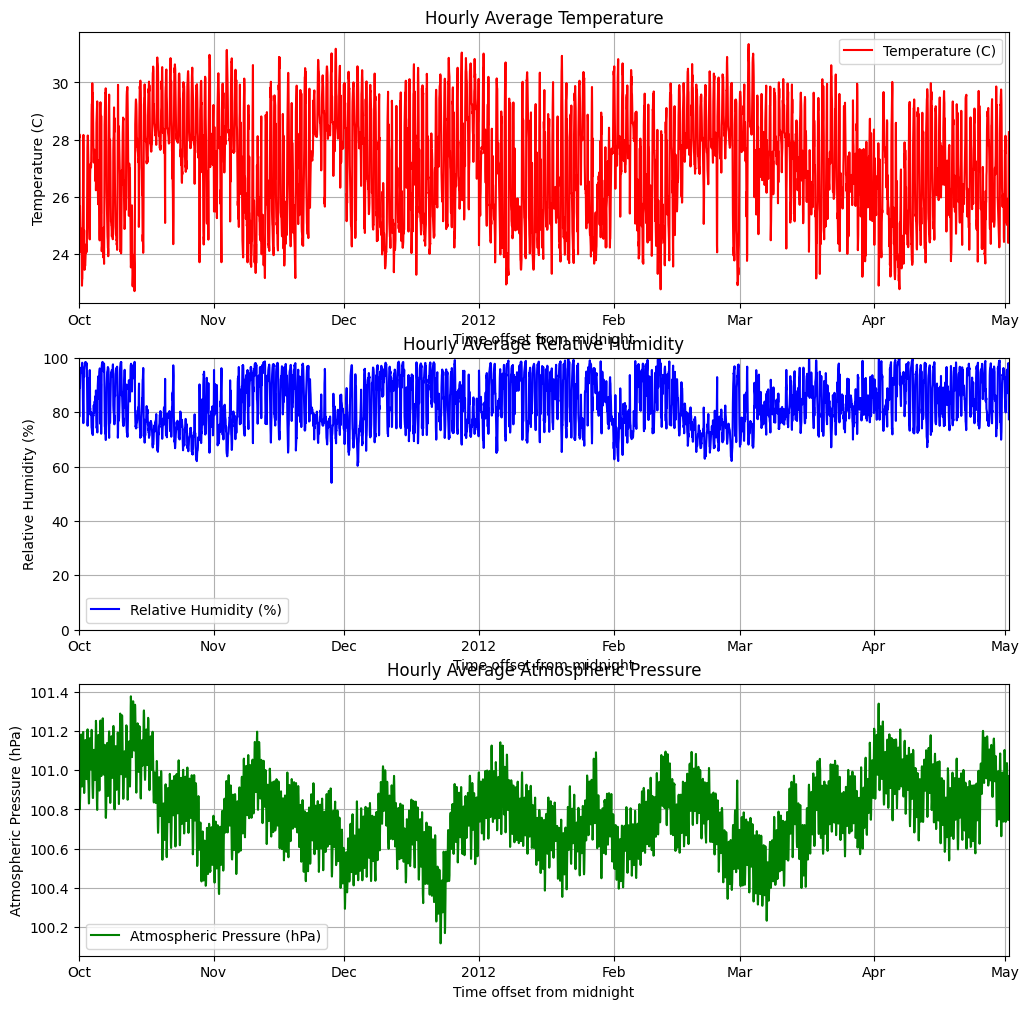

In [15]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(3,1, figsize=(12,12))

resam['temp_mean'].plot(ax=ax[0], color='red', label='Temperature (C)')
ax[0].set_title('Hourly Average Temperature')
ax[0].set_ylabel('Temperature (C)')
ax[0].legend()      

resam['rh_mean'].plot(ax=ax[1], color='blue', label='Relative Humidity (%)')
ax[1].set_title('Hourly Average Relative Humidity')
ax[1].set_ylabel('Relative Humidity (%)')
ax[1].legend()  
ax[1].set_ylim(0,100)

resam['atmos_pressure'].plot(ax=ax[2], color='green', label='Atmospheric Pressure (hPa)')
ax[2].set_title('Hourly Average Atmospheric Pressure')
ax[2].set_ylabel('Atmospheric Pressure (hPa)')
ax[2].legend()  

for a in ax:
    a.grid(True)
    a.set_xlim(resam.time.min().values, resam.time.max().values)


